In [1]:
import sys
import os
import pytest

from tqdm.notebook import tqdm, trange
import jax
jax.config.update("jax_enable_x64", True)
import jax.tree as jtu
import jax.numpy as np
import jax.random as jr
from jax import Array
from jax.flatten_util import ravel_pytree
import equinox as eqx
from zodiax.diffops import hessian
from zodiax.optimisation import eigen_projection

from optax import sgd, adam
import optimistix as optx

import amigo as amg
from amigo.stats import bin_data
import dorito as drt
from dorito.model_fits import PointResolvedFit as prf
from dorito.model_fits import ResolvedOIFit
from dorito.model_fits import _OIFit
from dorito.models import ResolvedAmigoModel
from dorito.models import ResolvedDiscoModel
from dorito.bases import ImageBasis
from dorito.models import BaseModeller
from dorito.stats import disco_regularised_loss_fn


from kneed import KneeLocator

import dLux.utils as dlu

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch
import ehtplot
import scienceplots
import cmasher as cmr

plt.style.use(["science", "bright", "no-latex"])
new_rcParams = {
    "svg.fonttype": "none",
    "image.cmap": "inferno",
    "font.family": "serif",
    "image.origin": "lower",
    "figure.dpi": 300,
    "font.size": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

from frito.autoencoder.ae_utils import load_classes_from_file as lcf, run_svd
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)
from frito.jax_gaussian import gaussian_filter
from frito.plot import main_mosaic
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
    disco_regularised_loss_forecast_fn as drl_forecast_fn,
    oi_log_likelihood_forecast as oi_ll_forecast,
    latent_gaussian_prior as lgp,
)

from frito.simulate import inject_image

In [2]:
master_key = jr.key(42)
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

ppd_51x51_data = np.load(ppd_51_path)
test_51x51_data = ppd_51x51_data["x_test"].astype('float64')

disco_HD100546_path = os.path.join(
    main_data_path, "jwst", "HD100546", "disco", "cal_vis_HD-100546.npy"
)
disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)

In [3]:
disco_PDS70 = np.load(disco_PDS70_path, allow_pickle=True).item()
disco_HD100546 = np.load(disco_HD100546_path, allow_pickle=True).item()
disco_HD135344B = np.load(disco_HD135344B_path, allow_pickle=True).item()

Model: 7_4
Model Struct: src/frito/autoencoder/model_structures/model_7_4.py
Trained Model Path: _data/autoencoder/trained_models/PPD/7_4_best.eqx
Autoencoder Classes: {'autoencoder': <class 'model_7_4.autoencoder'>, 'decoder': <class 'model_7_4.decoder'>, 'encoder': <class 'model_7_4.encoder'>}


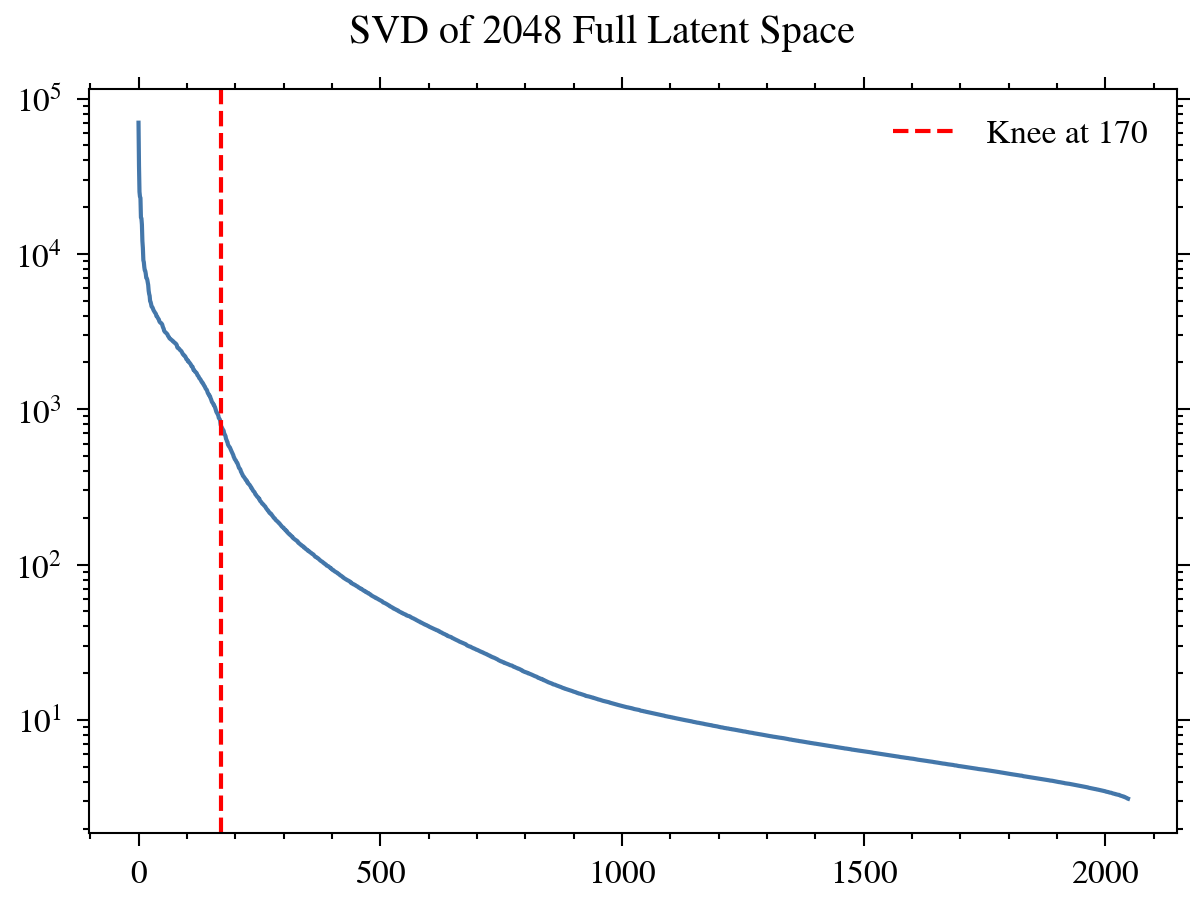

Suture Model Path: _data/autoencoder/trained_models/PPD/7_4_Rbest.eqx


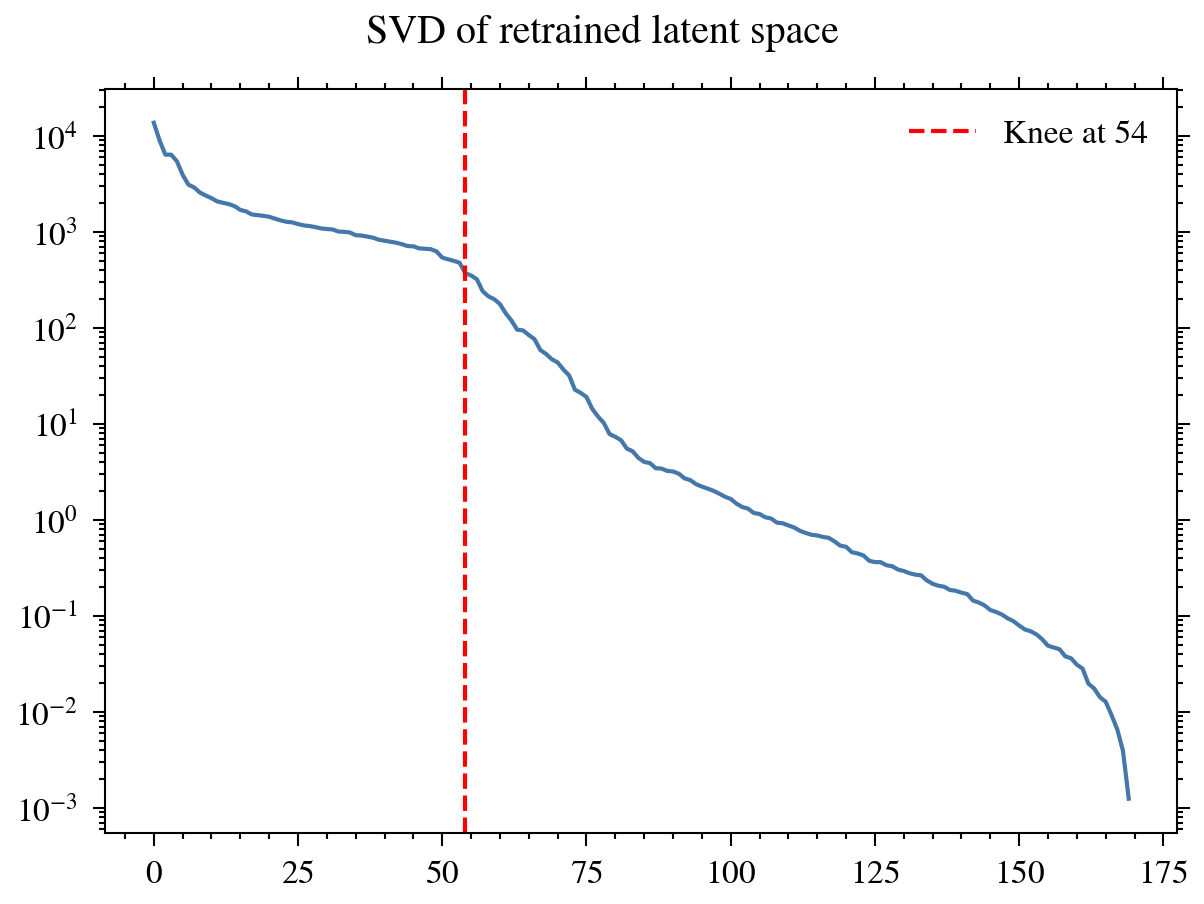

SVD Path: _data/autoencoder/svd/PPD_retrain_model_7_4_svd.npz
Knee at 54


Text(0.5, 1.0, 'Initial Distribution | Sum: 0.9999999999999998')

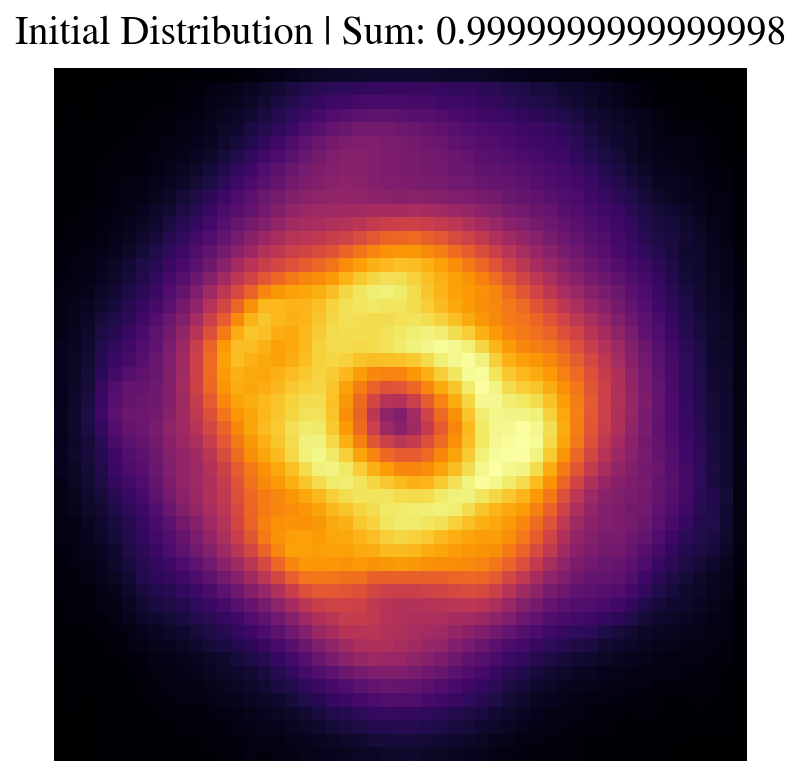

In [4]:
model_key, master_key = jr.split(master_key, 2)
model_type = "PPD"
i = 16
model_names = [
    "0_0",
    "0_2",
    "1_0",
    "1_2",
    "2_0",
    "2_1",
    "2_2",
    "3_0",
    "3_1",
    "3_2",
    "4_0",
    "4_1",
    "4_2",
    "7_0",
    "7_1",
    "7_2",
    "7_4",
    "7_5",
    "8_0",
    "8_2",
    "8_3",
    "8_4",
    "8_5",
    "8_6",
]
model_name = model_names[i]
model_struct_path = os.path.join(
    main_model_struct_path, f"model_{model_name}.py"
)
trained_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_best.eqx"
)
autoencoder_classes = lcf(model_struct_path)
autoencoder = autoencoder_classes["autoencoder"](key=model_key)
base_autoencoder = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

print(f"Model: {model_name}")
print(f"Model Struct: {model_struct_path}")
print(f"Trained Model Path: {trained_model_path}")
print(f"Autoencoder Classes: {autoencoder_classes}")

svd_path = os.path.join(
    main_svd_path, f"{model_type}_model_{model_name}_svd.npz"
)
svd = np.load(svd_path)

k1 = KneeLocator(
    np.arange(len(svd["s"])),
    svd["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of 2048 Full Latent Space")
ax.plot(svd["s"], marker=",")
ax.axvline(k1.knee, color="r", linestyle="--", label=f"Knee at {k1.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

tmp_keys = jr.split(master_key, 3)
suture_keys = tmp_keys[:2]
master_key = tmp_keys[2]

new_encode_in = base_autoencoder.modules[0].layers[-1].in_features
new_encode_out = int(k1.knee)
new_encode_latent_weights = (
    base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
)
new_encode_latent_biases = (
    base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
)
new_encode_linear = eqx.nn.Linear(
    in_features=new_encode_in, out_features=new_encode_out, key=suture_keys[0]
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.weight, new_encode_linear, new_encode_latent_weights
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_encode_linear, new_encode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers[-1],
    base_autoencoder,
    trained_new_encode_linear,
)


def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / 99999)


embed_layer = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers,
    sutured_ae_struct,
    sutured_ae_struct.modules[0].layers + [embed_layer],
)


def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / 99999)) @ v[:knee, :knee] + m[
        :knee
    ]


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers,
)

new_decode_out = sutured_ae_struct.modules[1].layers[2].out_features
new_decode_in = int(k1.knee)
new_decode_latent_weights = (
    sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
)
new_decode_latent_biases = sutured_ae_struct.modules[1].layers[2].bias
new_decode_linear = eqx.nn.Linear(
    in_features=new_decode_in, out_features=new_decode_out, key=suture_keys[1]
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.weight, new_decode_linear, new_decode_latent_weights
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_decode_linear, new_decode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers[2],
    sutured_ae_struct,
    trained_new_decode_linear,
)

sutured_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_Rbest.eqx"
)
sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
print(f"Suture Model Path: {sutured_model_path}")


def sum2unity(X):
    pix_sum = np.sum(X, axis=(1, 2), keepdims=True)
    norm_pix = X / pix_sum
    return norm_pix


sum2unity_layer = eqx.nn.Lambda(lambda z: sum2unity(z))
norm_sutured_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae,
    sutured_ae.modules[1].layers + [sum2unity_layer],
)

# encoder, decoder = sutured_ae.modules
encoder, decoder = norm_sutured_ae.modules

svd2_path = os.path.join(
    main_svd_path, f"{model_type}_retrain_model_{model_name}_svd.npz"
)
svd2 = np.load(svd2_path)
k2 = KneeLocator(
    np.arange(len(svd2["s"])),
    svd2["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of retrained latent space")
ax.plot(svd2["s"], marker=",")
ax.axvline(k2.knee, color="r", linestyle="--", label=f"Knee at {k2.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd2_path}")
print(f"Knee at {k2.knee}")

def embed2(X, m, s, v):
    return (X - m) @ v.T / np.sqrt(s**2 / 99999)


embed_layer2 = eqx.nn.Lambda(
    lambda z: embed2(z, svd2["mean"], svd2["s"], svd2["v"])
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[0].layers,
    norm_sutured_ae,
    norm_sutured_ae.modules[0].layers + [embed_layer2],
)


def unembed2(embedded, m, s, v):
    return ((embedded) * np.sqrt(s**2 / 99999)) @ v + m


unembed_layer2 = eqx.nn.Lambda(
    lambda z: unembed2(z, svd2["mean"], svd2["s"], svd2["v"])
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    norm2_sutured_ae,
    [unembed_layer2] + norm2_sutured_ae.modules[1].layers,  # [1:],
)
encoder, decoder = norm2_sutured_ae.modules

init_latent = np.zeros((170,))
init_dist = decoder(init_latent)
init_dist = init_dist[0]
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(init_dist)
ax.set_axis_off()
ax.set_title(f"Initial Distribution | Sum: {np.sum(init_dist)}")

In [5]:
idxs = iter([i for i in range(50, 1000)])


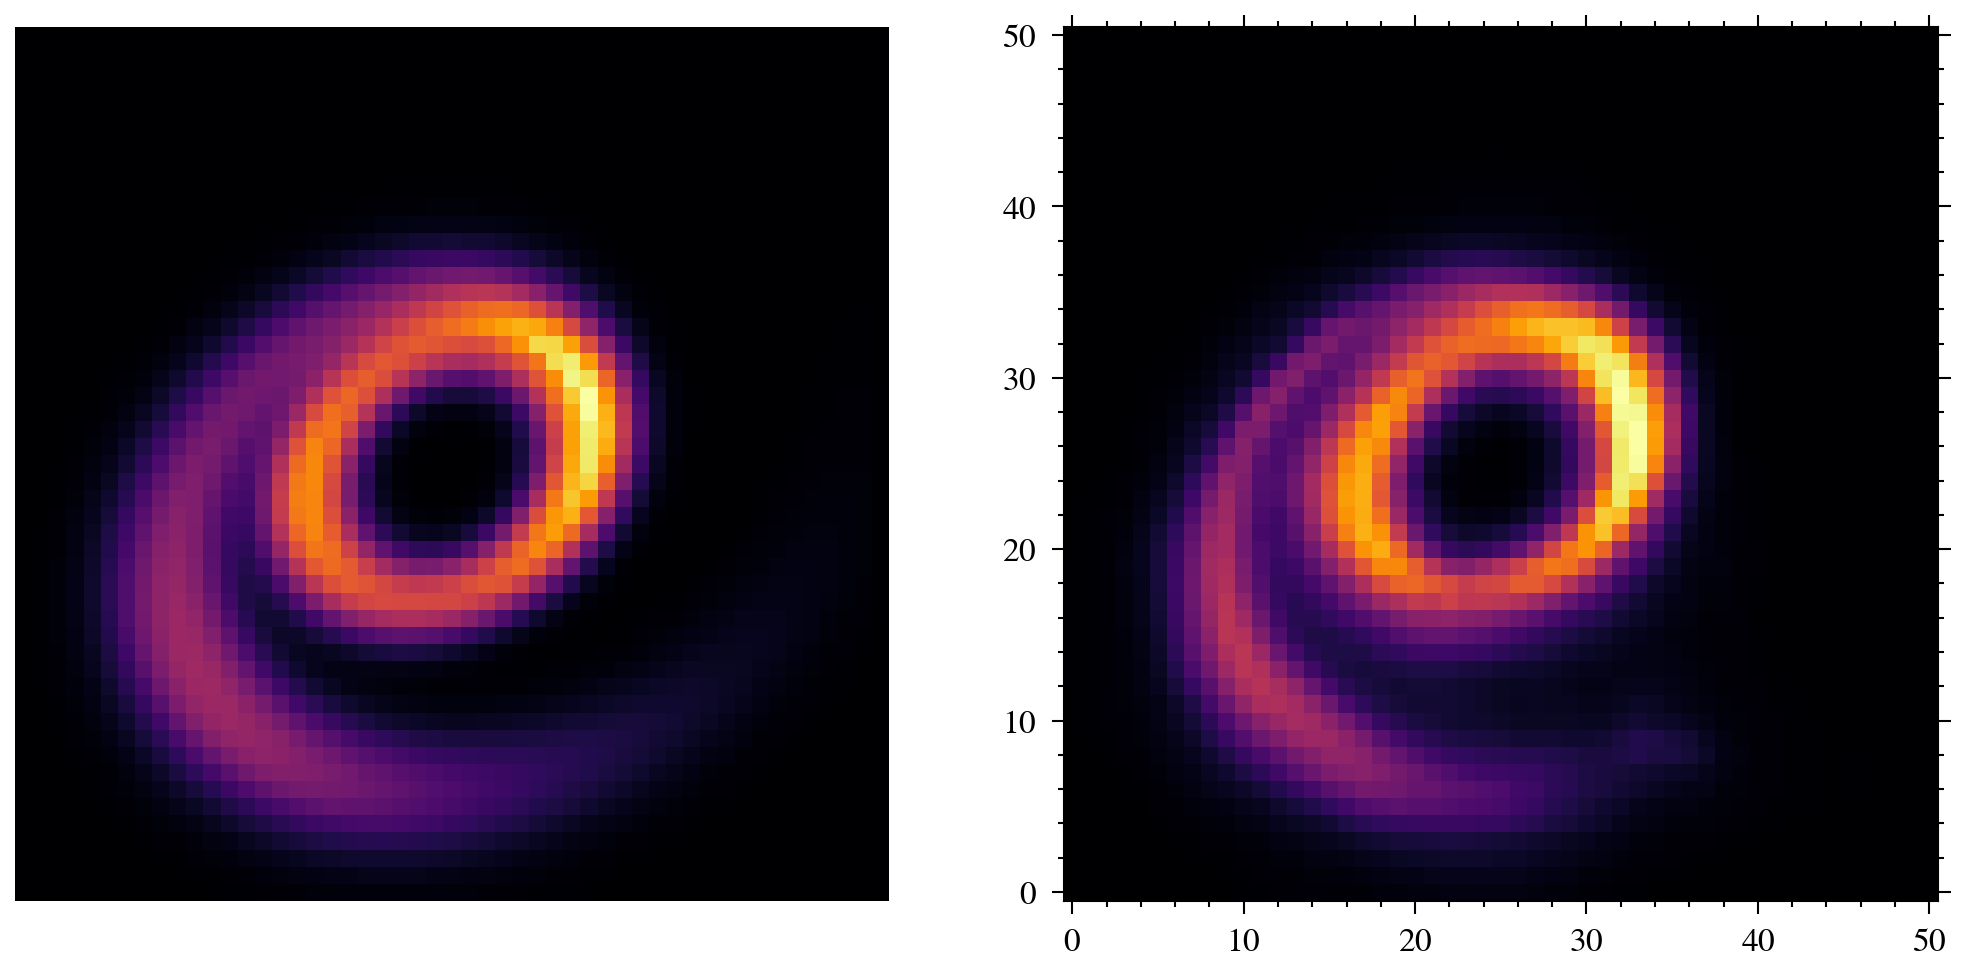

In [38]:
# PPD_idx = next(idxs)
# print(PPD_idx)
# ppd_image = test_51x51_data[PPD_idx]
ppd_image = test_51x51_data[71]

fig, axes = plt.subplots(1,2, figsize=(8.27, 8.27/2))
axes[0].imshow(ppd_image)
axes[0].set_axis_off()
axes[1].imshow(decoder(encoder(ppd_image.reshape(1,51,51)))[0])

15 23 25 26 27 29 31 33 34 61 71

In [88]:
injected_discos = inject_image(disco_PDS70,test_51x51_data[71], scale_noise_w_flux=False, pscale_mas=0.001)

In [89]:
# /np.max(test_51x51_data[71])

In [94]:
filter = "F380M"
n_epochs = 1000
ld_lr = 1e-2#2.55e-6#1e-5
c_lr =5e-9# 5e-8#5e-9#5e-10# 6e-10
# filter = "F430M"
# n_epochs = 1000
# ld_lr = 5e-6
# c_lr = 5e-10
# filter = "F480M"
# n_epochs = 1000
# ld_lr = 3e-5
# c_lr = 1e-10
prior = 1


In [95]:
basis = AutoencoderBasis(norm2_sutured_ae)
# ois = [
#     PROIF(
#         oi_data,
#         key,
#         filter=key,
#     )
#     for key, oi_data in disco_PDS70.items()
# ]
oi_data = injected_discos[filter]
ois = [PROIF(oi_data, filter, filter=filter)]

baselines = np.sqrt(ois[0].u**2+ois[0].v**2)
base_flat = np.tile(baselines, ois[0].vis_mat.shape[0])
threshold = 0.005
optics_diameter = base_flat[ois[0].vis_mat.flatten() > threshold].max()
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

model = PRDM(
    ois=ois,
    distribution=init_dist, # decoder(encoder(test_51x51_data[15].reshape(1,51,51)))[0],#init_dist,
    basis=basis,
    contrast=0.045,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=2.0,
)


def norm_fn(model_params, args):
    params = model_params.params

    # NOTE: This normalisation won't work for an arbitrary basis!
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            params["log_dist"][k] = log_dist
    return model_params.set("params", params), args


def grad_fn(model, grads, args):
    return grads, args


config = {
    # "log_dist": adam(1e-3, 0),
    "log_dist": adam(ld_lr, 0),  # adam(7.5e-4, 0),#adam(1e-3, 0),
    "contrast": sgd(c_lr, 0),
    # "contrast": sgd(2e-8, 100),
    # "log_dist": adam(5e-3, 0),
}


args = {
    "reg_dict": {"latent_gaussian_prior": (prior, lgp)},
    "basis": basis,
}
trainer = amg.fitting.Trainer(
    loss_fn=disco_regularised_loss_fn,
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache="_data/amigo/fisher",
)
trainer = trainer.update_fishers(
    model=model,
    exposures=ois,
    parameters=[],
)


result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epochs,
    batches=ois,
    args=args,
)
frito_model = result.model


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 7,111.27
Estimated run time: 0:00:20
Full Time: 0:00:17
Final Loss: -863.62


In [96]:
def run_filter_bfgs(
    model, oi, filter_name, args, max_steps=500, rtol=1e-8, atol=1e-8
):
    x_map = {
        "log_dist": model.params["log_dist"][filter_name],
        "contrast": model.params["contrast"][filter_name],
    }

    def neg_log_post(x):
        new_log_dist = dict(model.params["log_dist"])
        new_log_dist[filter_name] = x["log_dist"]
        new_contrast = dict(model.params["contrast"])
        new_contrast[filter_name] = x["contrast"]
        new_params = dict(model.params)
        new_params["log_dist"] = new_log_dist
        new_params["contrast"] = new_contrast
        m = eqx.tree_at(lambda mm: mm.params, model, new_params)
        loss, _ = disco_regularised_loss_fn(m, oi, args)
        return loss

    forecast = np.array(oi(model))

    def neg_log_post_forecast(x, forecast):
        new_log_dist = dict(model.params["log_dist"])
        new_log_dist[filter_name] = x["log_dist"]
        new_contrast = dict(model.params["contrast"])
        new_contrast[filter_name] = x["contrast"]
        new_params = dict(model.params)
        new_params["log_dist"] = new_log_dist
        new_params["contrast"] = new_contrast
        m = eqx.tree_at(lambda mm: mm.params, model, new_params)
        loss, _ = drl_forecast_fn(m, oi, forecast, args)
        return loss

    # DIAGNOSTICS
    f0 = float(neg_log_post(x_map))
    g0 = jax.grad(neg_log_post)(x_map)
    g0_flat, _ = ravel_pytree(g0)
    print(
        f"[{filter_name}] loss={f0:.3e}, "
        f"‖grad‖_inf={float(np.max(np.abs(g0_flat))):.3e}"
    )

    # HESSIAN

    print(f"[{filter_name}] computing Hessian...")
    H, _ = hessian(
        lambda x: neg_log_post_forecast(x, forecast),
        x_map,
        nbatches=1,
        jit=True,
    )

    def safe_fisher(H, floor_rel=1e-8):
        """Symmetrise H and reconstruct it with eigenvalues floored to be
        strictly positive. The result is PSD and safe to pass to eigen_projection."""
        H_sym = 0.5 * (H + H.T)
        vals, vecs = np.linalg.eigh(H_sym)
        floor = floor_rel * np.max(
            np.abs(vals)
        )  # use abs in case max is negative
        vals_clipped = np.clip(vals, floor, None)
        return (vecs * vals_clipped) @ vecs.T

    H_safe = safe_fisher(H)
    P = eigen_projection(fmat=H_safe)

    X0, unravel = ravel_pytree(x_map)
    n = X0.size

    def project_fn(u):
        return X0 + P @ u

    # Projected loss for BFGS
    @jax.jit
    def projected_loss(u, _args):
        return neg_log_post(unravel(project_fn(u)))

    # running bfgs
    print(f"[{filter_name}] running BFGS in latent space...")
    solver = optx.BestSoFarMinimiser(optx.BFGS(rtol=rtol, atol=atol))

    u0 = np.zeros(n)

    sol = optx.minimise(
        projected_loss,
        solver,
        u0,
        args=None,
        max_steps=max_steps,
        throw=False,
    )

    # project back into param space
    u_opt = sol.value
    x_opt = unravel(project_fn(u_opt))

    # ---- Diagnostics after ----
    f1 = float(neg_log_post(x_opt))
    g1 = jax.grad(neg_log_post)(x_opt)
    g1_flat, _ = ravel_pytree(g1)
    print(
        f"[{filter_name}] after:  loss={f1:.3e}, "
        f"‖grad‖_inf={float(np.max(np.abs(g1_flat))):.3e}, "
        f"steps={int(sol.stats['num_steps'])}, "
        f"result={optx.RESULTS[sol.result]}"
    )

    # Write back into model
    new_log_dist = dict(model.params["log_dist"])
    new_log_dist[filter_name] = x_opt["log_dist"]
    new_contrast = dict(model.params["contrast"])
    new_contrast[filter_name] = x_opt["contrast"]
    new_params = dict(model.params)
    new_params["log_dist"] = new_log_dist
    new_params["contrast"] = new_contrast
    new_model = eqx.tree_at(lambda mm: mm.params, model, new_params)

    return {
        "model": new_model,
        "x_opt": x_opt,
        "u_opt": u_opt,
        "loss_before": f0,
        "loss_after": f1,
        "grad_inf_before": float(np.max(np.abs(g0_flat))),
        "grad_inf_after": float(np.max(np.abs(g1_flat))),
        "H_before": H,
        "P": P,
        "X0": X0,
        "sol": sol,
    }


bfgs_results = {}
for oi in ois:
    fname = oi.filter
    bfgs_result = run_filter_bfgs(
        frito_model, oi, fname, args, max_steps=1000, rtol=1e-12, atol=1e-12
    )
    bfgs_results[fname] = bfgs_result
bfgs_model = bfgs_results[filter]["model"]

[F380M] loss=-8.637e+02, ‖grad‖_inf=6.777e+01
[F380M] computing Hessian...
[F380M] running BFGS in latent space...
[F380M] after:  loss=-9.239e+02, ‖grad‖_inf=2.080e+00, steps=951, result=


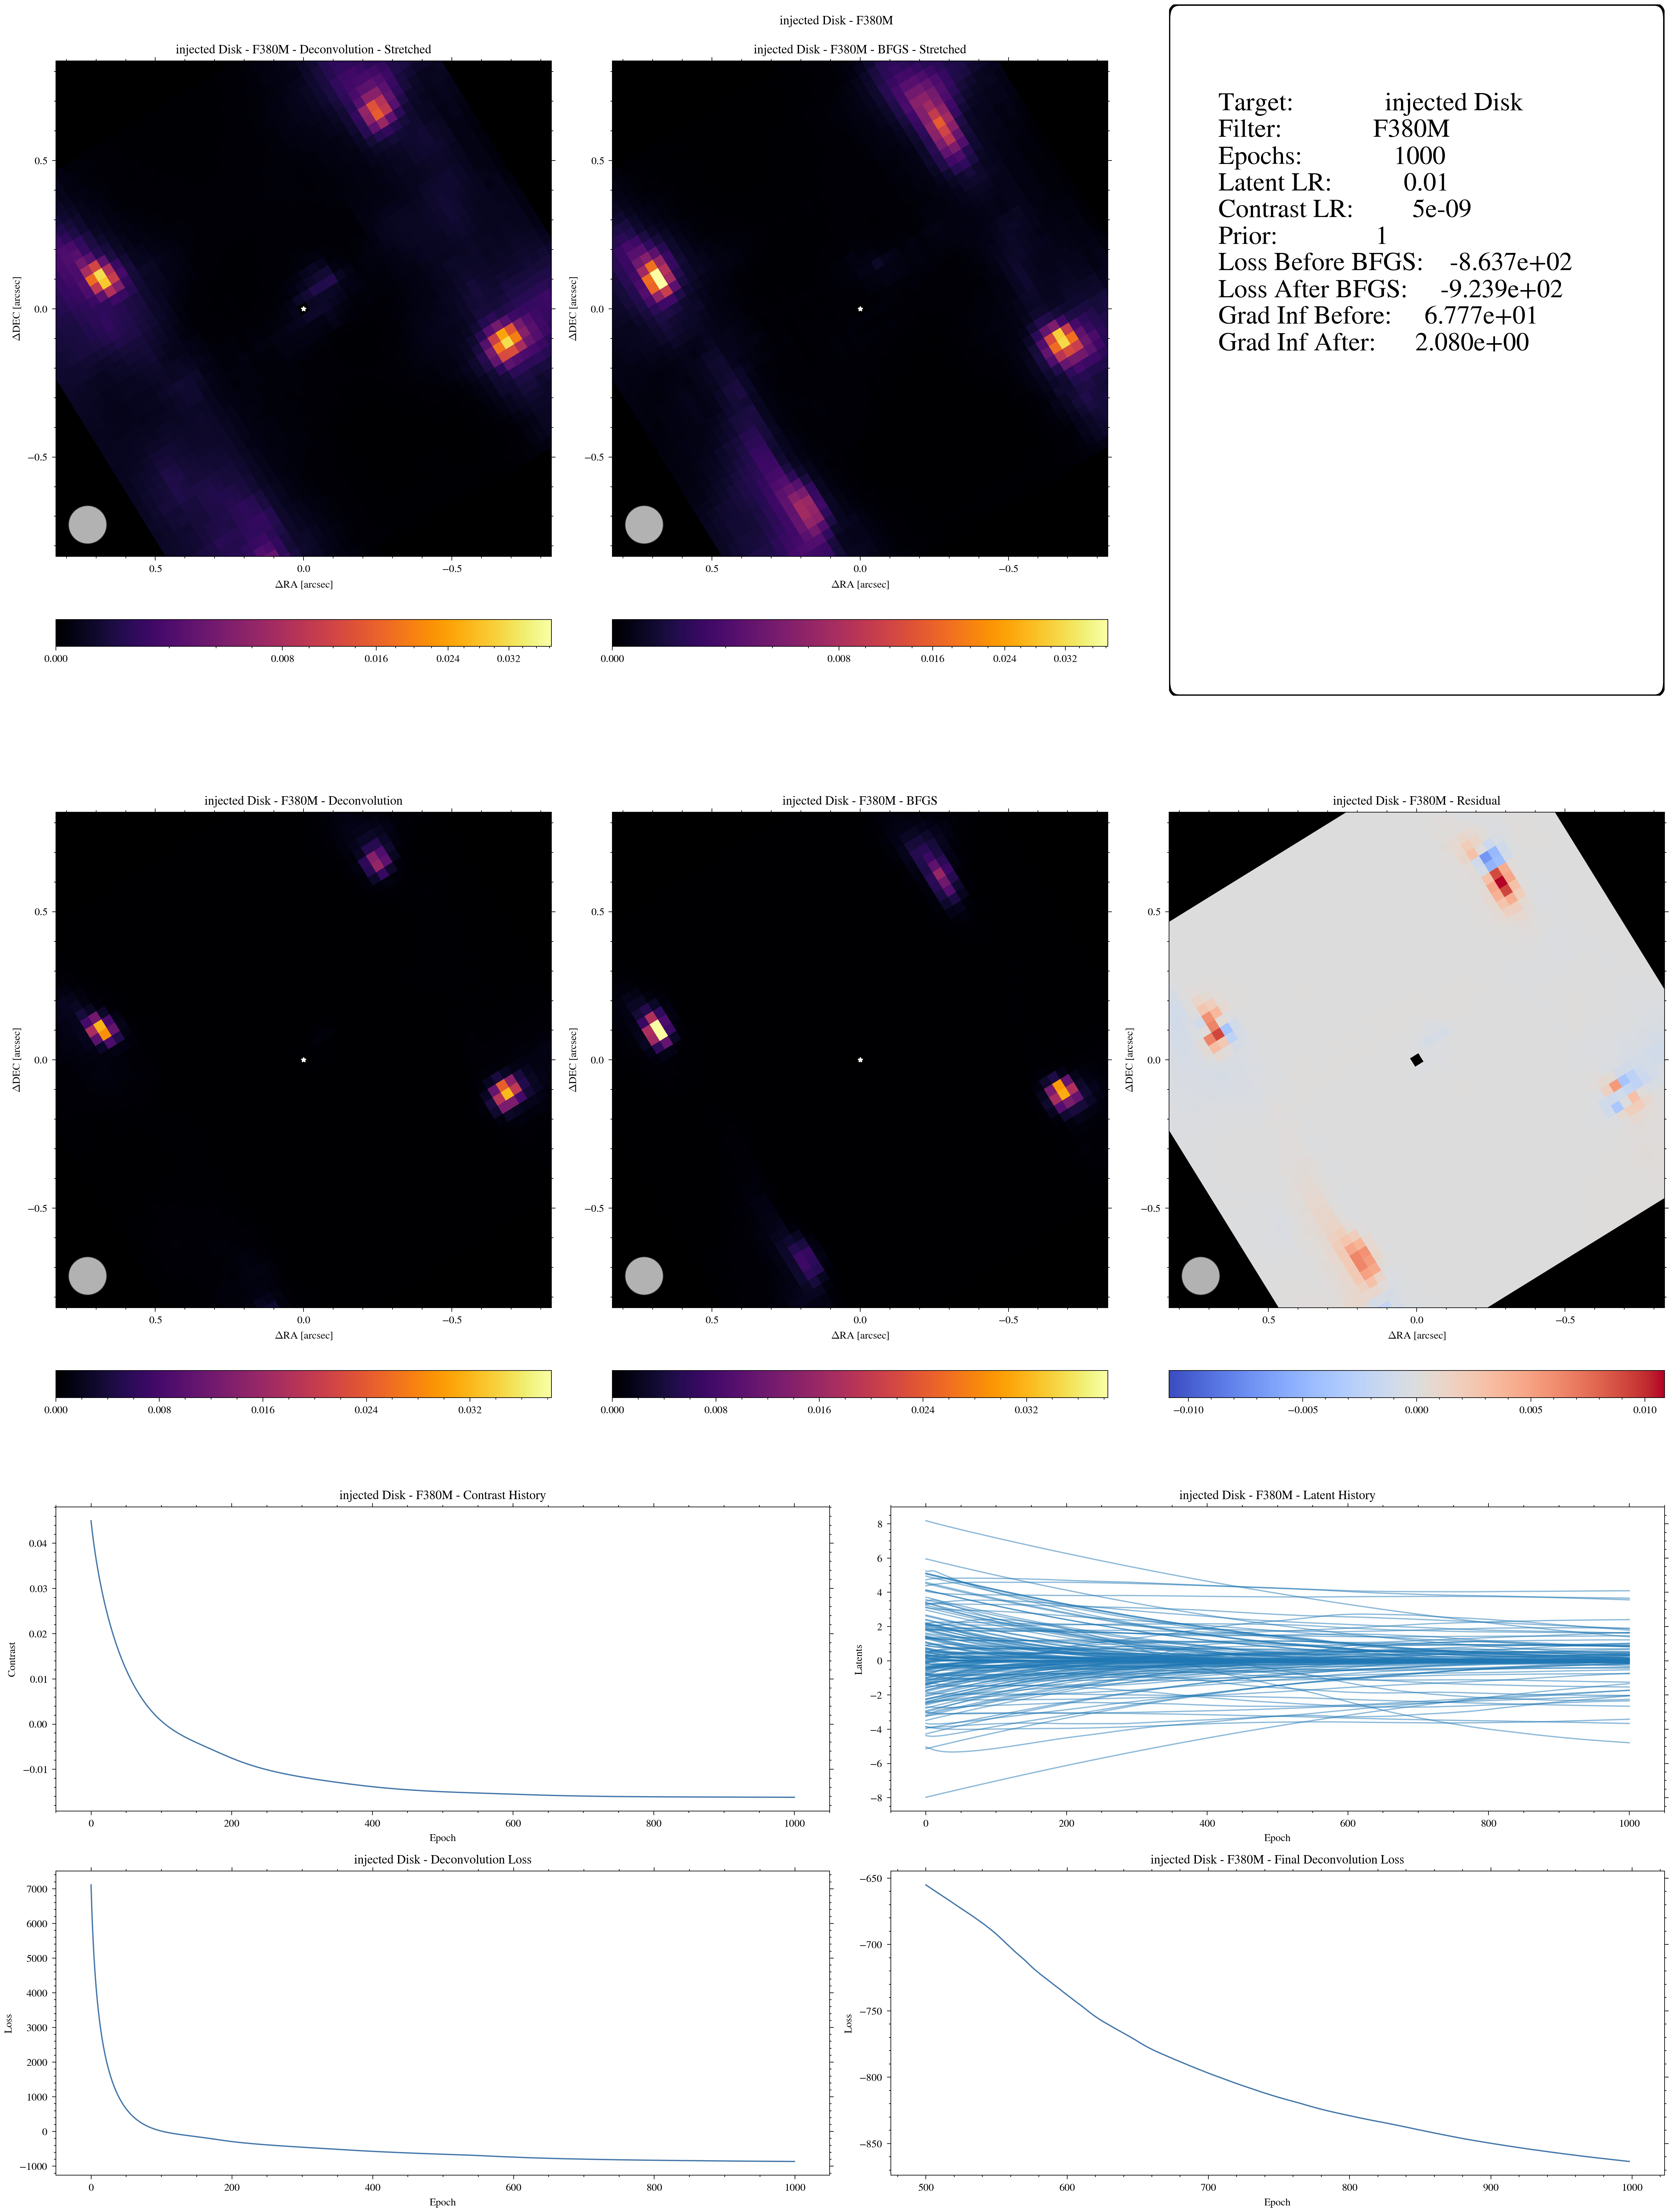

In [97]:
mosaic = main_mosaic(
    "injected Disk",
    filter,
    ois,
    optics_diameter,
    frito_model,
    deconvolution_result=result,
    bfgs_model=bfgs_model,
    bfgs_result=bfgs_results[filter],
    epochs=n_epochs,
    log_dist_lr=ld_lr,
    contrast_lr=c_lr,
    prior=prior,
)